# Python Exceptions and Errors

An **exception** is an event that disrupts a program's normal execution flow — a Python object (ultimately derived from `BaseException`) carrying the error type, the program's state when it happened, and a descriptive message.

**Why use exceptions?**
- Standardized, precisely-named error handling.
- Cleaner code — error handling logic stays separate from the main logic.
- More robust applications, since failures can be handled gracefully instead of crashing.
- Automatic propagation — an unhandled exception in a deeply nested function bubbles up the call stack until something catches it, with no manual forwarding needed.

**Note:** every `input()` call in this notebook is simulated (pre-supplied values, echoed to output) so the notebook runs unattended.

In [ ]:
import builtins

def simulate_input(*responses):

    it = iter(responses)

    def fake_input(prompt=""):

        val = next(it)

        print(f"{prompt}{val}")

        return val

    builtins.input = fake_input



_real_input = input

def restore_input():

    builtins.input = _real_input

## Errors: Syntax vs. Logical

- **Syntax errors** (a.k.a. parsing errors) — the code doesn't follow Python's grammar at all; the interpreter refuses to even START running it. Common causes: bad indentation, a missing colon/comma/bracket, keywords in the wrong place.
- **Logical errors (exceptions)** — the code IS syntactically valid, but something goes wrong while it's actually RUNNING. This is what `try`/`except` is for.

In [ ]:
try:

    exec('if True:\nprint("bad indent")\n    print("oops")')

except IndentationError as e:

    print("IndentationError:", e)

In [ ]:
a = 10

b = 20

try:

    print("Addition:", a + c)   # 'c' was never defined - a LOGICAL error, valid syntax

except NameError as e:

    print("NameError:", e)

## Common Built-in Exceptions

| Exception | Raised when... |
|---|---|
| `AssertionError` | an `assert` statement fails |
| `AttributeError` | attribute assignment or reference fails |
| `EOFError` | `input()` hits end-of-file |
| `ImportError` | an imported module/name isn't found |
| `IndexError` | a sequence index is out of range |
| `KeyError` | a dict key isn't found |
| `KeyboardInterrupt` | the user hits Ctrl+C |
| `MemoryError` | an operation runs out of memory |
| `NameError` | a variable isn't found in scope |
| `TypeError` | an operation is applied to an incompatible type |
| `ValueError` | a value has the right type but an invalid value |
| `ZeroDivisionError` | division (or modulo) by zero |
| `FileNotFoundError` | a file doesn't exist on disk |

In [ ]:
try:

    fp = open("this_file_does_not_exist.txt", "r")

except FileNotFoundError as e:

    print("FileNotFoundError:", e)

## The `try`/`except` Block

Code that MIGHT fail ('risky code') goes in `try`; the recovery logic goes in `except`. Without this, an exception TERMINATES the program abnormally.

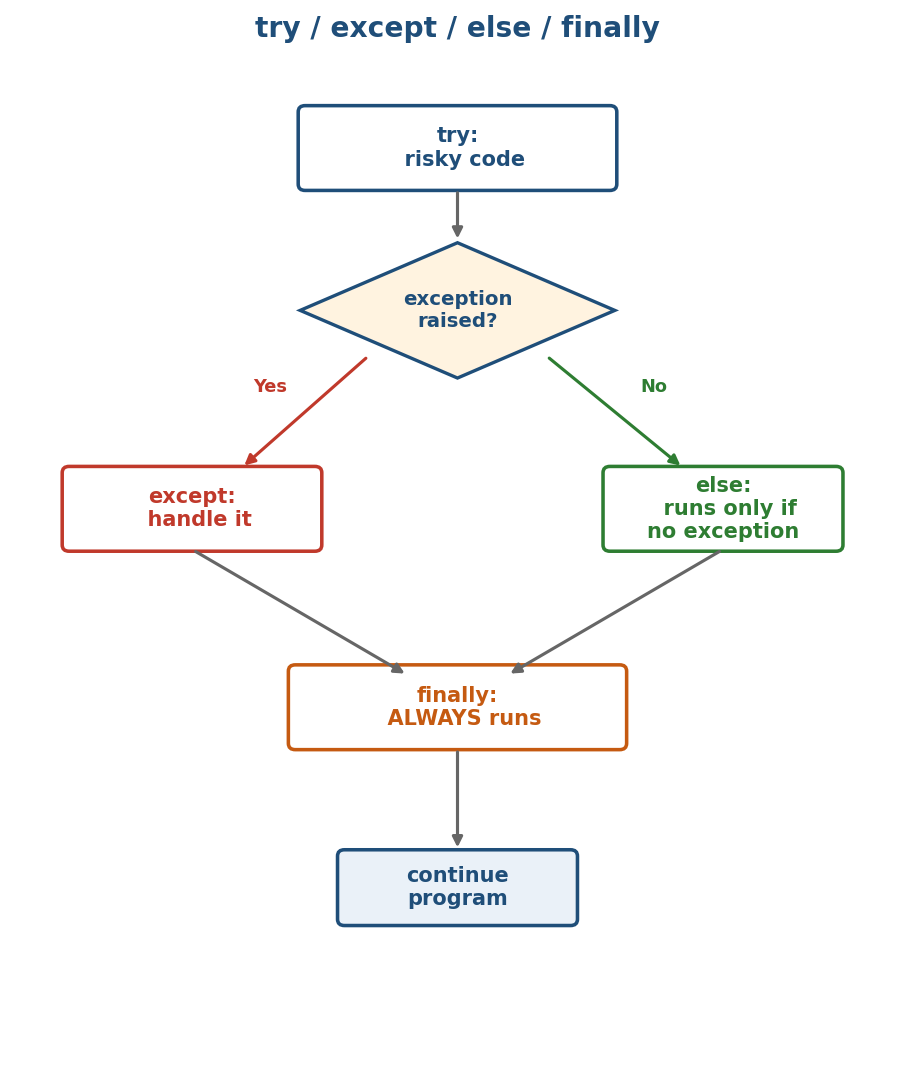

In [ ]:
try:

    a = 10

    b = 0

    c = a / b

    print("The answer of a divide by b:", c)

except:

    print("Can't divide with zero. Provide different number")

### Catching a SPECIFIC Exception

A bare `except:` catches EVERYTHING — including bugs you didn't anticipate, which can hide real problems. Naming the exact exception you expect is better practice. Multiple `except` clauses can follow one `try`; only the FIRST matching one runs.

In [ ]:
simulate_input("Ten")

try:

    a = int(input("Enter value of a:"))

    b = int(input("Enter value of b:"))

    c = a / b

    print("The answer of a divide by b:", c)

except ValueError:

    print("Entered value is wrong")

except ZeroDivisionError:

    print("Can't divide by zero")

restore_input()

In [ ]:
simulate_input("10", "0")

try:

    a = int(input("Enter value of a:"))

    b = int(input("Enter value of b:"))

    c = a / b

    print("The answer of a divide by b:", c)

except ValueError:

    print("Entered value is wrong")

except ZeroDivisionError:

    print("Can't divide by zero")

restore_input()

### Handling Multiple Exceptions in ONE `except` Clause

In [ ]:
simulate_input("Ten", "5")

try:

    a = int(input("Enter value of a:"))

    b = int(input("Enter value of b:"))

    c = a / b

    print("The answer of a divide by b:", c)

except (ValueError, ZeroDivisionError):

    print("Please enter a valid value")

restore_input()

## `try` With `finally`

The `finally` block ALWAYS runs — whether the `try` succeeded, raised a handled exception, or even raised an UNHANDLED one. It's the standard place to release resources (close a file, a network connection) that must be cleaned up no matter what happened.

In [ ]:
simulate_input("20", "5")

try:

    a = int(input("Enter value of a:"))

    b = int(input("Enter value of b:"))

    c = a / b

    print("The answer of a divide by b:", c)

except ZeroDivisionError:

    print("Can't divide with zero")

finally:

    print("Inside a finally block")

restore_input()

In [ ]:
simulate_input("20", "0")

try:

    a = int(input("Enter value of a:"))

    b = int(input("Enter value of b:"))

    c = a / b

    print("The answer of a divide by b:", c)

except ZeroDivisionError:

    print("Can't divide with zero")

finally:

    print("Inside a finally block")   # runs EVEN when the exception fired

restore_input()

## `try` With `else`

The `else` block runs ONLY IF the `try` block completed with NO exception at all — useful for code that should run after success, but that you specifically DON'T want wrapped inside the `try` itself (so it doesn't accidentally get blamed for, or swallow, unrelated exceptions).

In [ ]:
simulate_input("20", "4")

try:

    a = int(input("Enter value of a:"))

    b = int(input("Enter value of b:"))

    c = a / b

    print("a/b = %d" % c)

except ZeroDivisionError:

    print("Can't divide by zero")

else:

    print("We are in else block")

restore_input()

In [ ]:
simulate_input("20", "0")

try:

    a = int(input("Enter value of a:"))

    b = int(input("Enter value of b:"))

    c = a / b

    print("a/b = %d" % c)

except ZeroDivisionError:

    print("Can't divide by zero")

else:

    print("We are in else block")   # SKIPPED - the exception fired

restore_input()

## Raising Exceptions With `raise`

`raise` deliberately triggers an exception yourself — for validation failures, or any situation where the caller genuinely needs to know something went wrong.

In [ ]:
def simple_interest(amount, year, rate):

    try:

        if rate > 100:

            raise ValueError(rate)

        interest = (amount * year * rate) / 100

        print('The Simple Interest is', interest)

        return interest

    except ValueError:

        print('interest rate is out of range', rate)



print('Case 1')

simple_interest(800, 6, 8)



print('Case 2')

simple_interest(800, 6, 800)

## Exception Chaining

`raise NewException(...) from original_exception` links two exceptions together — the traceback shows BOTH, making it clear the new exception was triggered WHILE handling the original one. This preserves the full story of what actually went wrong, rather than losing the original cause.

In [ ]:
try:

    a, b = 10, 0

    c = a / b

except ZeroDivisionError as e:

    try:

        raise ValueError("Division failed") from e

    except ValueError as ve:

        print("Caught:", ve)

        print("Original cause:", ve.__cause__)

## Custom (User-Defined) Exceptions

Define your own exception by subclassing `Exception` (directly or indirectly) — lets you signal precisely what went wrong, in your own domain's vocabulary, rather than reusing a generic built-in exception that doesn't quite fit.

In [ ]:
class Error(Exception):

    """Base class for other exceptions"""

    pass



class ValueTooSmallError(Error):

    """Raised when the input value is too small"""

    pass



class ValueTooLargeError(Error):

    """Raised when the input value is too large"""

    pass



simulate_input("5", "60", "11")



while True:

    num = int(input("Enter any value in 10 to 50 range: "))

    try:

        if num < 10:

            raise ValueTooSmallError

        elif num > 50:

            raise ValueTooLargeError

        break

    except ValueTooSmallError:

        print("Value is below range..try again")

    except ValueTooLargeError:

        print("value out of range...try again")



print("Great! value in correct range.")

restore_input()

### Customizing an Exception Class With Its Own Data

A custom exception can accept and store its own arguments, just like any class — useful for carrying extra context (like the actual bad value) along with the error.

In [ ]:
class NegativeAgeError(Exception):

    def __init__(self, age):

        self.age = age

        self.message = "Age should not be negative"

        super().__init__(self.message)



simulate_input("-9")

age = int(input("Enter age: "))

try:

    if age < 0:

        raise NegativeAgeError(age)

except NegativeAgeError as e:

    print(f"Caught NegativeAgeError: {e.message} (got {e.age})")

restore_input()

## Exception Lifecycle (Propagation)

When an exception is raised, Python searches BACKWARD through the call stack (the chain of function calls that led to this point) looking for a matching `except`. If one is found, the exception is handled there; if none is found anywhere in the whole chain, the program terminates and a full traceback (showing every function call involved, with line numbers) is printed.

In [ ]:
def sum_of_list(numbers):

    return sum(numbers)



def average(total, n):

    return total / n   # ZeroDivisionError if the list was empty



def final_data(data):

    for item in data:

        try:

            print("Average:", average(sum_of_list(item), len(item)))

        except ZeroDivisionError:

            print("Average: cannot compute - empty list")



list1 = [10, 20, 30, 40, 50]

list2 = [100, 200, 300, 400, 500]

list3 = []   # empty - would raise ZeroDivisionError if unhandled



final_data([list1, list2, list3])

(This version wraps the risky call in its OWN `try`/`except` so the loop continues cleanly for every list; without that inner handling, a `ZeroDivisionError` triggered by `list3` would propagate all the way up and terminate the whole program, exactly as described above.)

## Warnings

Not every built-in exception-like signal STOPS the program — several represent **warnings**, which just flag a possible issue without halting execution. Common warning classes: `UserWarning`, `DeprecationWarning` (a feature is going away), `PendingDeprecationWarning`, `SyntaxWarning`, `RuntimeWarning`, `FutureWarning`, `ResourceWarning`.

In [ ]:
import warnings



def old_function():

    warnings.warn("old_function() is deprecated, use new_function() instead", DeprecationWarning)

    return 42



with warnings.catch_warnings(record=True) as caught:

    warnings.simplefilter("always")

    result = old_function()

    print("Function still returned:", result)

    print("Warning category:", caught[0].category.__name__)

    print("Warning message:", str(caught[0].message))

## Summary

- **Syntax errors** stop the program before it even runs; **exceptions (logical errors)** happen DURING execution and can be caught.
- `try`/`except` catches and handles exceptions gracefully — always prefer naming a SPECIFIC exception over a bare `except:`.
- `finally` always runs, for guaranteed cleanup; `else` runs only when the `try` succeeded with no exception.
- `raise` deliberately triggers an exception; `raise ... from ...` chains it to an original cause for a fuller traceback.
- Custom exceptions (subclassing `Exception`) let you signal precisely what went wrong in your own domain's terms, and can carry their own extra data.
- An unhandled exception propagates automatically up the entire call stack until either something catches it or the program terminates.
- Warnings flag possible issues WITHOUT stopping execution, unlike exceptions.

## Practice Exercises

1. Write a function `safe_divide(a, b)` that returns the division result, or a friendly error message string if `b` is zero — using `try`/`except`, no manual `if` check.
2. Write a function `get_list_item(lst, index)` that returns the item at `index`, or `None` if the index is out of range, using `try`/`except IndexError`.
3. Create a custom exception `InsufficientFundsError` and use it inside a `withdraw(balance, amount)` function that raises it (with the shortfall amount as data) when `amount > balance`.
4. Write a function that opens a file, using `try`/`finally` to guarantee the file handle is closed even if reading it raises an exception (simulate this WITHOUT a real missing file, using a deliberately-raised exception inside the `try` instead).
5. Write a loop using `try`/`except`/`else` that keeps asking for a positive integer, printing a success message via `else` only once a genuinely valid one is given, then breaks.

### Exercise 1 solution

In [ ]:
def safe_divide(a, b):

    try:

        return a / b

    except ZeroDivisionError:

        return "Cannot divide by zero"



print(safe_divide(10, 2))

print(safe_divide(10, 0))

### Exercise 2 solution

In [ ]:
def get_list_item(lst, index):

    try:

        return lst[index]

    except IndexError:

        return None



print(get_list_item([1, 2, 3], 1))

print(get_list_item([1, 2, 3], 10))

### Exercise 3 solution

In [ ]:
class InsufficientFundsError(Exception):

    def __init__(self, shortfall):

        self.shortfall = shortfall

        super().__init__(f"Insufficient funds - short by {shortfall}")



def withdraw(balance, amount):

    if amount > balance:

        raise InsufficientFundsError(amount - balance)

    return balance - amount



try:

    withdraw(100, 150)

except InsufficientFundsError as e:

    print("Error:", e, "| shortfall amount:", e.shortfall)

### Exercise 4 solution

In [ ]:
class FakeFile:

    def __init__(self, name):

        self.name = name

        self.closed = False

    def close(self):

        self.closed = True

        print(f"{self.name} closed.")



def read_and_process(fp):

    try:

        print("Reading file...")

        raise ValueError("Simulated corrupt data in file")

    finally:

        fp.close()   # guaranteed to run, even though the try block raised



f = FakeFile("data.txt")

try:

    read_and_process(f)

except ValueError as e:

    print("Caught:", e)

print("File closed status:", f.closed)

### Exercise 5 solution

In [ ]:
simulate_input("-5", "abc", "7")



while True:

    raw = input("Enter a positive integer: ")

    try:

        value = int(raw)

        if value <= 0:

            raise ValueError("must be positive")

    except ValueError:

        print("Invalid input, try again.")

    else:

        print("Got a valid positive integer:", value)

        break

restore_input()